# AEGIS-RF — гібридна байєсівська просторова ідентифікація Wi-Fi у КІІ
## Adversary-rEsistant Geolocation & Integrity for wi-fi Signals

Прикладний демонстраційний ноутбук **за Розділом 1** дисертаційного дослідження:
просторова ідентифікація джерел IEEE 802.11 у критичній інформаційній інфраструктурі
(КІІ) зі злиттям **RSSI-радіокарти** та **FTM/RTT-дальнометрії**, **робастністю** до
навмисних маніпуляцій (evil twin, deceptive ranging, deauth) і **доказовою атрибуцією**
(Spatial Attribution Record) для інтеграції із SOC/SIEM/SOAR.

> ⚠️ **Демонстраційні дані.** Усі числа характеризують синтетичну модель, параметри якої
> задані автором, а не реальні вимірювання. Ноутбук ілюструє методологію та перевіряє
> відтворюваність обчислень.

**Реалізовані компоненти розділу:**
> 1.1 моделі загроз (rogue AP / evil twin / deauth) · 1.2 RSSI-fingerprinting і
> байєсівська локалізація · 1.3 FTM/RTT-дальнометрія · 1.4 гібридне злиття
> правдоподібностей і робастний інференс · 1.5 доказова атрибуція та SOC/SIEM.

---
### ▶ Як запустити в Google Colab
Ноутбук **самодостатній** — він не потребує клонування репозиторію чи зовнішніх файлів.
Усі бібліотеки (`numpy`, `matplotlib`, `pandas`) уже є в середовищі Colab.

1. Відкрийте ноутбук у Colab (*File → Upload notebook*, або *Open → GitHub*).
2. Меню **Runtime → Run all** (або `Ctrl+F9`).
3. Рисунки з'являться під клітинками, а артефакти збережуться у теки `results/` та
   `figures/` середовища виконання (їх видно у панелі *Files* зліва).

## 0. Налаштування середовища / Setup

Фіксуємо зерно генератора `SEED = 80211` (за номером стандарту IEEE 802.11), задаємо
глобальні параметри експерименту та єдиний стиль рисунків. Одне зерно на весь ноутбук
гарантує **побітову відтворюваність**: повторний *Run all* дає ті самі числа й рисунки.

In [1]:
# ============================================================
# Імпорти та глобальна конфігурація
# ============================================================
# Ноутбук самодостатній: у Colab ці пакети вже встановлені. Якщо запускаєте
# локально й чогось бракує — розкоментуйте наступний рядок:
# !pip -q install numpy matplotlib pandas

import os, json, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display

warnings.filterwarnings("ignore")

# --- Відтворюваність --------------------------------------------------------
SEED = 80211                       # єдине зерно на весь експеримент
N_EVENTS  = 240                    # кількість подій (джерел сигналу)
SCENARIOS = ["clean", "evil_twin", "deceptive_ranging", "deauth"]
METHODS   = ["rssi", "ftm", "fusion", "robust"]

# --- Єдиний стиль рисунків ---------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "figure.facecolor": "white", "savefig.bbox": "tight",
})
# Кольори та підписи методів — послідовні на всіх рисунках
CMETH = {"rssi": "#4C72B0", "ftm": "#DD8452", "fusion": "#55A868", "robust": "#C44E52"}
LMETH = {"rssi": "RSSI", "ftm": "FTM/RTT", "fusion": "Наївне злиття", "robust": "Робастне злиття"}

# Теки для артефактів (таблиці, рисунки, доказові записи)
for d in ("results", "figures"):
    os.makedirs(d, exist_ok=True)

print("SEED:", SEED, "| подій:", N_EVENTS, "| сценаріїв:", len(SCENARIOS),
      "| методів:", len(METHODS))
print("NumPy:", np.__version__, "| pandas:", pd.__version__)

SEED: 80211 | подій: 240 | сценаріїв: 4 | методів: 4
NumPy: 2.4.6 | pandas: 3.0.3


## 1. Середовище КІІ та радіомодель / CII environment & radio model

Синтетичне приміщення $30\times24$ м із **шістьма точками доступу (AP)** IEEE 802.11.
Частина AP підтримує **FTM/RTT** (точну часову дальнометрію). Виділено **критичну зону**
(напр. серверна) у правій частині приміщення. Джерела сигналу («події») розподілені
рівномірно, причому ≈ 45 % припадає на критичну зону.

**Модель RSSI (log-distance path loss).** Очікуваний рівень сигналу від AP на відстані
$d$:
$$\overline{RSSI}(d) = P_0 - 10\,n\,\log_{10}(d/d_0),$$
де $P_0$ — потужність на опорній відстані $d_0=1$ м, $n$ — показник загасання. Реальні
виміри мають гаусове «затінення» (shadowing) $\mathcal{N}(0,\sigma_{RSSI}^2)$.

**Модель FTM/RTT.** Виміряна дальність $\hat d = d + \varepsilon$, де
$\varepsilon\sim\mathcal{N}(0,\sigma_{FTM}^2)$, з випадковим додатним зсувом на NLOS-лінках
(перешкода на шляху сигналу подовжує виміряну відстань).

In [2]:
# ============================================================
# Геометрія приміщення та радіомодель
# ============================================================
ROOM_W, ROOM_H = 30.0, 24.0              # розміри приміщення, м
CRIT_ZONE = (20.0, 2.0, 29.0, 11.0)      # критична зона: (x0, y0, x1, y1)

# Параметри радіоканалу
TX_P0     = -40.0   # RSSI на опорній відстані d0=1 м, дБм
PLE       = 2.8     # показник загасання (path-loss exponent)
D0        = 1.0     # опорна відстань, м
SIGMA_RSSI = 3.0    # СКВ затінення RSSI, дБ
SIGMA_FTM  = 1.2    # СКВ похибки FTM-дальнометрії, м
NLOS_PROB  = 0.12   # ймовірність NLOS-зсуву на FTM-лінку
NLOS_BIAS  = 4.0    # середній додатний NLOS-зсув дальності, м

# Точки доступу: координати (x, y) та ознака підтримки FTM
APS = np.array([[1.5, 1.5], [28.5, 1.5], [1.5, 22.5],
                [28.5, 22.5], [15.0, 12.0], [24.5, 6.5]])
AP_FTM   = np.array([True, False, True, False, True, True])   # 4 з 6 підтримують FTM
AP_NAMES = [f"AP{i+1}" for i in range(len(APS))]


def in_zone(p, z=CRIT_ZONE):
    '''Булева маска: чи потрапляє точка (чи масив точок) у прямокутну зону.'''
    x0, y0, x1, y1 = z
    p = np.atleast_2d(p)
    return (p[:, 0] >= x0) & (p[:, 0] <= x1) & (p[:, 1] >= y0) & (p[:, 1] <= y1)


def expected_rssi(points, aps):
    '''Очікуваний (безшумний) RSSI від кожного AP у кожній точці — модель радіокарти.'''
    d = np.linalg.norm(points[:, None, :] - aps[None, :, :], axis=2)  # відстані точка↔AP
    d = np.maximum(d, D0)                                             # уникаємо log(0)
    return TX_P0 - 10.0 * PLE * np.log10(d / D0)


class Env:  # простий контейнер для стану середовища
    pass


def build_env(rng):
    '''Побудова радіокарти (RP-сітка), сітки кандидатів та подій.'''
    # 1) RP-сітка радіокарти (survey points) — крок 1.5 м
    gx, gy = np.arange(1.0, ROOM_W, 1.5), np.arange(1.0, ROOM_H, 1.5)
    RX, RY = np.meshgrid(gx, gy)
    rp = np.column_stack([RX.ravel(), RY.ravel()])
    rp_rssi = expected_rssi(rp, APS)                 # еталонні відбитки RSSI

    # 2) Сітка кандидатів для локалізації (густіша, крок 0.75 м)
    cx, cy = np.arange(0.5, ROOM_W, 0.75), np.arange(0.5, ROOM_H, 0.75)
    CX, CY = np.meshgrid(cx, cy)
    cand = np.column_stack([CX.ravel(), CY.ravel()])
    cand_rssi = expected_rssi(cand, APS)

    # 3) Події: ~45 % примусово в критичній зоні, решта — по всьому приміщенню
    n_crit = int(round(0.45 * N_EVENTS))
    x0, y0, x1, y1 = CRIT_ZONE
    crit = np.column_stack([rng.uniform(x0, x1, n_crit), rng.uniform(y0, y1, n_crit)])
    free = np.column_stack([rng.uniform(0.5, ROOM_W - 0.5, N_EVENTS - n_crit),
                            rng.uniform(0.5, ROOM_H - 0.5, N_EVENTS - n_crit)])
    pos = np.vstack([crit, free])[rng.permutation(N_EVENTS)]

    e = Env()
    e.rp, e.rp_rssi = rp, rp_rssi
    e.cand, e.cand_rssi, e.cand_shape = cand, cand_rssi, CX.shape
    e.pos, e.true_zone = pos, in_zone(pos)
    return e


# Будуємо середовище з фіксованим зерном
env = build_env(np.random.default_rng(SEED))
print(f"RP-сітка радіокарти : {len(env.rp)} точок")
print(f"Сітка кандидатів    : {len(env.cand)} точок ({env.cand_shape[1]}×{env.cand_shape[0]})")
print(f"Подій               : {len(env.pos)} (у критичній зоні: {int(env.true_zone.sum())})")
print(f"Точок доступу       : {len(APS)} (з FTM: {int(AP_FTM.sum())})")

RP-сітка радіокарти : 320 точок
Сітка кандидатів    : 1280 точок (40×32)
Подій               : 240 (у критичній зоні: 126)
Точок доступу       : 6 (з FTM: 4)


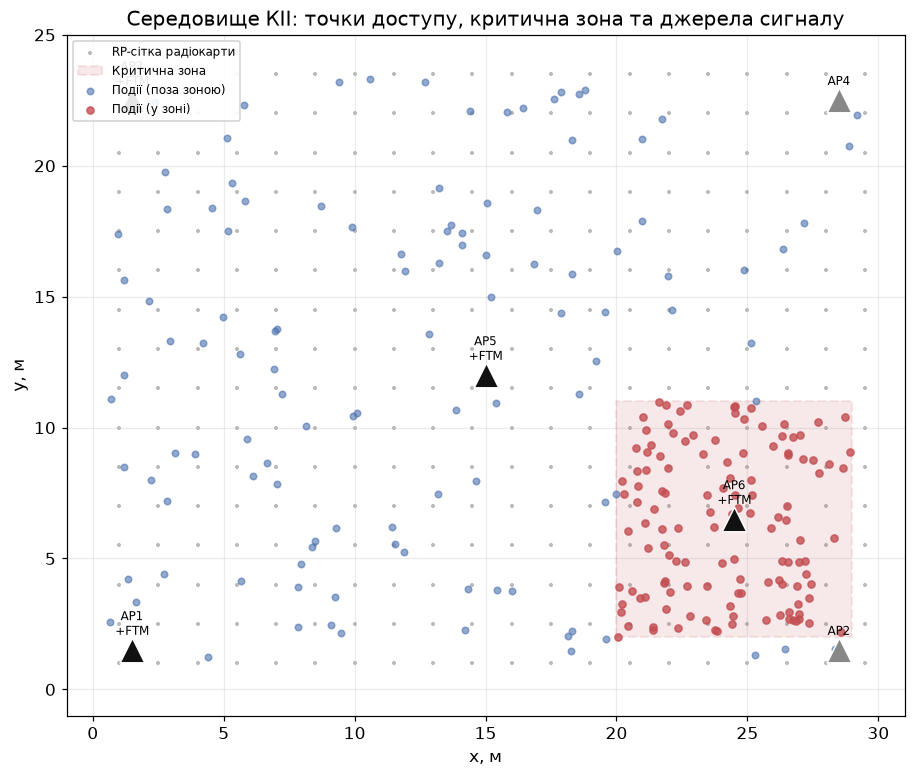

In [3]:
# ------------------------------------------------------------
# Рисунок 1. Карта середовища: AP, критична зона, події
# ------------------------------------------------------------
def zone_patch(ax):
    '''Малює прямокутник критичної зони на осях.'''
    x0, y0, x1, y1 = CRIT_ZONE
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fc="#C44E52", ec="#C44E52",
                           alpha=0.12, lw=1.5, ls="--", label="Критична зона"))

fig, ax = plt.subplots(figsize=(9, 7.2))
ax.scatter(env.rp[:, 0], env.rp[:, 1], s=8, c="#BBBBBB", marker="+",
           label="RP-сітка радіокарти")
zone_patch(ax)
ax.scatter(*env.pos[~env.true_zone].T, s=18, c="#4C72B0", alpha=0.6, label="Події (поза зоною)")
ax.scatter(*env.pos[env.true_zone].T,  s=22, c="#C44E52", alpha=0.8, label="Події (у зоні)")
for i, (x, y) in enumerate(APS):                     # трикутники — точки доступу
    ax.scatter(x, y, s=260, marker="^", c="#111111" if AP_FTM[i] else "#888888",
               edgecolors="white", zorder=5)
    ax.annotate(AP_NAMES[i] + ("\n+FTM" if AP_FTM[i] else ""), (x, y),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
ax.set(xlim=(-1, ROOM_W + 1), ylim=(-1, ROOM_H + 1), xlabel="x, м", ylabel="y, м",
       title="Середовище КІІ: точки доступу, критична зона та джерела сигналу")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9); ax.set_aspect("equal")
fig.tight_layout(); fig.savefig("figures/fig1_environment.png"); plt.show()

### Радіокарта RSSI / RSSI radiomap

Байєсівська локалізація спирається на **радіокарту** — очікуваний RSSI у кожній точці
приміщення для кожного AP. Нижче — теплові карти для двох AP: значення спадають радіально
від AP згідно з моделлю log-distance. Саме ці поверхні порівнюються з виміряним RSSI під
час інференсу.

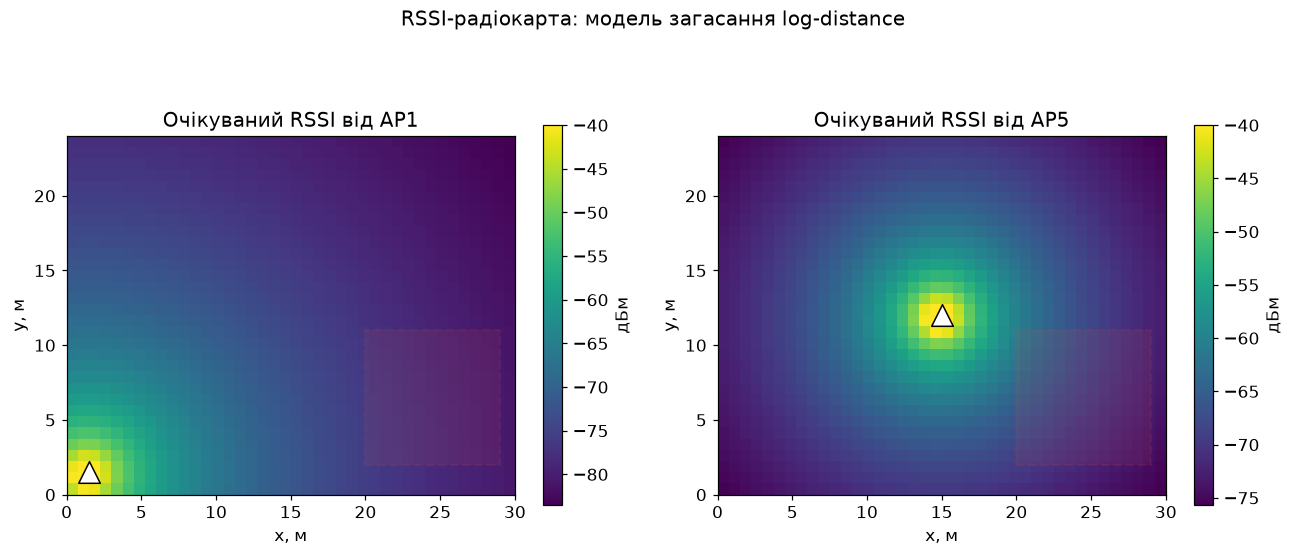

In [4]:
# ------------------------------------------------------------
# Рисунок 2. Радіокарта RSSI для двох AP (теплові карти)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, j in zip(axes, (0, 4)):                      # AP1 (кут) та AP5 (центр)
    grid = env.cand_rssi[:, j].reshape(env.cand_shape)
    im = ax.imshow(grid, origin="lower", extent=[0, ROOM_W, 0, ROOM_H],
                   cmap="viridis", aspect="equal")
    ax.scatter(*APS[j], s=200, marker="^", c="white", edgecolors="black", zorder=5)
    zone_patch(ax)
    ax.set(title=f"Очікуваний RSSI від {AP_NAMES[j]}", xlabel="x, м", ylabel="y, м")
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8, label="дБм")
fig.suptitle("RSSI-радіокарта: модель загасання log-distance", y=1.02)
fig.tight_layout(); fig.savefig("figures/fig2_radiomap.png"); plt.show()

## 2. Спостереження та моделі загроз / Observations & threat models

Для кожної події генеруємо зашумлені виміри RSSI (від усіх AP) і FTM-дальності (лише від
FTM-AP). Далі накладаємо один із **чотирьох сценаріїв** (модель супротивника, п. 1.1):

| Сценарій | Що відбувається | Скомпрометована модальність |
|---|---|---|
| `clean` | атак немає, лише природний шум | — |
| `evil_twin` | rogue-AP клонує **AP1** біля зловмисника й завищує RSSI (жертва «бачить» його ближчим) | RSSI |
| `deceptive_ranging` | FTM-AP (**AP5**) маніпулює часовими мітками й занижує дальність | FTM |
| `deauth` | deauth-флуд «вимикає» **AP6** — його виміри зникають | доступність AP |

In [5]:
# ============================================================
# Генерація спостережень із моделями загроз
# ============================================================
class Obs:  # контейнер спостережень одного сценарію
    pass


def simulate(env, scenario, rng):
    '''Зашумлені RSSI+FTM виміри з накладанням атаки конкретного сценарію.'''
    n = N_EVENTS
    # --- Природні виміри (без атак) --------------------------------------
    rssi = expected_rssi(env.pos, APS) + rng.normal(0, SIGMA_RSSI, (n, len(APS)))
    d_true = np.linalg.norm(env.pos[:, None, :] - APS[None, :, :], axis=2)
    ftm = d_true + rng.normal(0, SIGMA_FTM, d_true.shape)
    nlos = rng.random(d_true.shape) < NLOS_PROB               # випадкові NLOS-лінки
    ftm += nlos * np.abs(rng.normal(NLOS_BIAS, 1.5, d_true.shape))

    ap_avail = np.ones(len(APS), bool)
    compromised = {}

    # --- Накладання атаки -------------------------------------------------
    if scenario == "evil_twin":
        j = 0                                                 # rogue клонує AP1
        rssi[:, j] += rng.normal(12.0, 2.0, n)                # завищений RSSI → «ближче»
        compromised = {"ap": AP_NAMES[j], "type": "rssi_spoof"}
    elif scenario == "deceptive_ranging":
        j = 4                                                 # AP5 занижує дальність
        ftm[:, j] = np.maximum(0.5, ftm[:, j] - rng.normal(7.0, 1.5, n))
        compromised = {"ap": AP_NAMES[j], "type": "ftm_spoof"}
    elif scenario == "deauth":
        j = 5                                                 # AP6 вимкнено флудом
        ap_avail[j] = False
        compromised = {"ap": AP_NAMES[j], "type": "deauth_drop"}

    o = Obs()
    o.rssi, o.ftm = rssi, ftm
    o.rssi_ok = ap_avail                       # доступні AP для RSSI
    o.ftm_ok = AP_FTM & ap_avail               # доступні AP для FTM
    o.ap_avail, o.compromised, o.scenario = ap_avail, compromised, scenario
    return o


# Окреме (детерміноване) зерно на кожен сценарій — стабільно між запусками
scen_obs = {sc: simulate(env, sc, np.random.default_rng(SEED + 101 * (i + 1)))
            for i, sc in enumerate(SCENARIOS)}

for sc, o in scen_obs.items():
    tag = o.compromised.get("type", "—")
    print(f"{sc:18s} | скомпрометовано: {o.compromised.get('ap', '—'):>4s} ({tag}) "
          f"| доступних AP: {int(o.ap_avail.sum())}/{len(APS)}")

clean              | скомпрометовано:    — (—) | доступних AP: 6/6
evil_twin          | скомпрометовано:  AP1 (rssi_spoof) | доступних AP: 6/6
deceptive_ranging  | скомпрометовано:  AP5 (ftm_spoof) | доступних AP: 6/6
deauth             | скомпрометовано:  AP6 (deauth_drop) | доступних AP: 5/6


## 3. Байєсівська локалізація та злиття / Bayesian localization & fusion

Для кожної події перебираємо **сітку кандидатних позицій** і оцінюємо логарифм
правдоподібності. Внесок кожного AP — гаусів член:

* **RSSI:** $-\tfrac12\big((\overline{RSSI}_{\text{cand}} - RSSI_{\text{вим}})/\sigma_{RSSI}\big)^2$
* **FTM:** $-\tfrac12\big((d_{\text{cand}} - \hat d_{\text{вим}})/\sigma_{FTM}\big)^2$

Порівнюємо **чотири методи**:

* **RSSI** — лише радіокарта;
* **FTM/RTT** — лише часова дальнометрія;
* **Наївне злиття** — сума лог-правдоподібностей обох модальностей;
* **Робастне злиття** — те саме з **ітеративним відсіюванням AP-викидів** (MAD-гейт):
  на кожній ітерації знаходимо AP із аномально великим залишком у поточній MAP-оцінці й
  вилучаємо його. Саме це дає стійкість до evil twin / deceptive ranging.

Оцінка позиції — **апостеріорне середнє** по сітці; додатково рахуємо апостеріорну
**невизначеність** $\sigma$ та **ймовірність критичної зони** $P(\text{зона})$.

In [6]:
# ============================================================
# Функції правдоподібності та локалізація
# ============================================================
def loglik_rssi(env, rssi_row, mask):
    '''Лог-правдоподібність за RSSI по доступних AP (mask).'''
    diff = env.cand_rssi[:, mask] - rssi_row[mask]
    return -0.5 * np.sum((diff / SIGMA_RSSI) ** 2, axis=1)


def loglik_ftm(env, ftm_row, mask):
    '''Лог-правдоподібність за FTM-дальністю по доступних FTM-AP (mask).'''
    d = np.linalg.norm(env.cand[:, None, :] - APS[None, mask, :], axis=2)
    return -0.5 * np.sum((d - ftm_row[mask]) ** 2 / SIGMA_FTM ** 2, axis=1)


def posterior(ll):
    '''Нормована апостеріорна щільність із лог-правдоподібності (softmax).'''
    p = np.exp(ll - ll.max())
    s = p.sum()
    return p / s if s > 0 else np.ones_like(p) / len(p)


def _mad_gate(residuals, active, min_keep):
    '''Повертає індекс AP-викиду за MAD-критерієм або None.'''
    if len(active) <= min_keep:
        return None
    r = residuals[active]
    med = np.median(r)
    mad = np.median(np.abs(r - med)) + 1e-9
    worst = active[np.argmax(r)]
    if (r.max() - med) / (1.4826 * mad) > 3.5 and r.max() > 3.0:
        return worst
    return None


def localize_event(env, obs, i, method):
    '''Локалізація однієї події. Повертає (оцінка, σ, P(зона), апостеріор).'''
    rmask, fmask = obs.rssi_ok.copy(), obs.ftm_ok.copy()

    if method == "rssi":
        ll = loglik_rssi(env, obs.rssi[i], rmask)
    elif method == "ftm":
        ll = loglik_ftm(env, obs.ftm[i], fmask)
    elif method == "fusion":
        ll = loglik_rssi(env, obs.rssi[i], rmask) + loglik_ftm(env, obs.ftm[i], fmask)
    elif method == "robust":
        # Ітеративне відсіювання AP-викидів (до 3 проходів)
        for _ in range(3):
            ll = loglik_rssi(env, obs.rssi[i], rmask) + loglik_ftm(env, obs.ftm[i], fmask)
            k = np.argmax(ll)                                    # поточна MAP-позиція
            res_r = np.abs(env.cand_rssi[k] - obs.rssi[i]) / SIGMA_RSSI
            res_f = np.abs(np.linalg.norm(env.cand[k] - APS, axis=1) - obs.ftm[i]) / SIGMA_FTM
            bad_r = _mad_gate(res_r, np.where(rmask)[0], min_keep=3)
            bad_f = _mad_gate(res_f, np.where(fmask)[0], min_keep=2)
            if bad_r is None and bad_f is None:
                break
            if bad_r is not None: rmask[bad_r] = False
            if bad_f is not None: fmask[bad_f] = False
        ll = loglik_rssi(env, obs.rssi[i], rmask) + loglik_ftm(env, obs.ftm[i], fmask)
    else:
        raise ValueError(method)

    post = posterior(ll)
    est = post @ env.cand                                        # апостеріорне середнє
    var = post @ np.sum((env.cand - est) ** 2, axis=1)
    p_zone = post[in_zone(env.cand)].sum()                       # маса в критичній зоні
    return est, float(np.sqrt(var)), float(p_zone), post


print("Функції локалізації визначено. Методи:", METHODS)

Функції локалізації визначено. Методи: ['rssi', 'ftm', 'fusion', 'robust']


### Приклад апостеріорної щільності / Posterior for one event

Щоб зрозуміти інференс, візьмемо **одну подію в критичній зоні** під атакою `evil_twin` і
покажемо апостеріорну щільність робастного методу. Пік зосереджений біля істинної позиції
(★), оцінка (✕) поруч, а вся ймовірнісна маса лежить у критичній зоні — тому подія
впевнено маркується як критична.

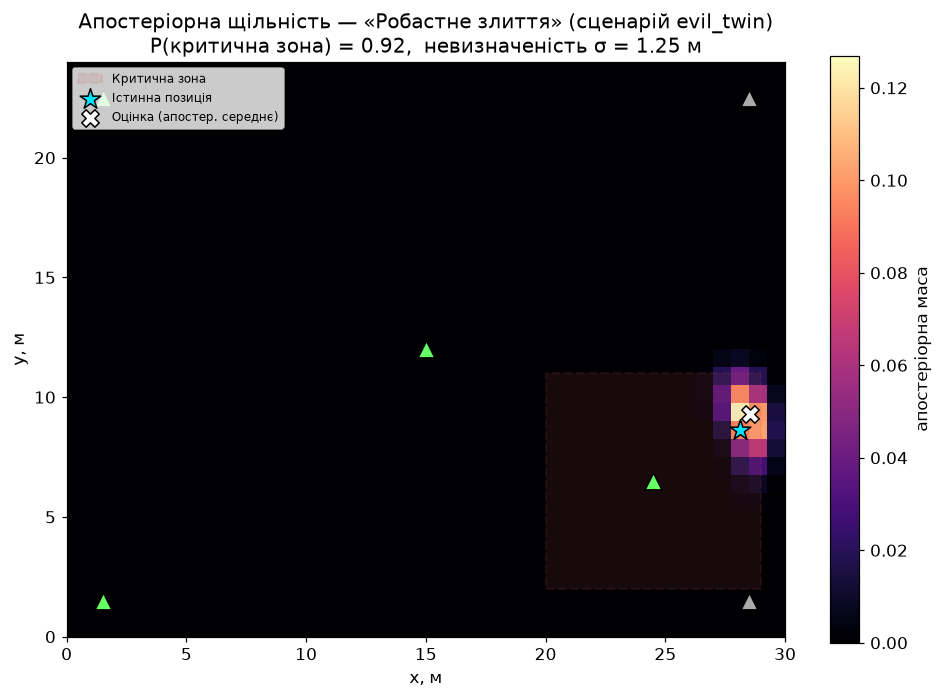

In [7]:
# ------------------------------------------------------------
# Рисунок 3. Апостеріорна щільність для однієї події
# ------------------------------------------------------------
obs_demo = scen_obs["evil_twin"]
idx = int(np.where(env.true_zone)[0][0])                 # перша подія в зоні
est, sd, pz, post = localize_event(env, obs_demo, idx, "robust")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(post.reshape(env.cand_shape), origin="lower",
               extent=[0, ROOM_W, 0, ROOM_H], cmap="magma", aspect="equal")
zone_patch(ax); ax.grid(False)
ax.scatter(*env.pos[idx], s=200, marker="*", c="#00E5FF", edgecolors="black",
           zorder=6, label="Істинна позиція")
ax.scatter(*est, s=130, marker="X", c="white", edgecolors="black", zorder=6,
           label="Оцінка (апостер. середнє)")
for i, (x, y) in enumerate(APS):
    ax.scatter(x, y, s=120, marker="^", c="#66FF66" if AP_FTM[i] else "#AAAAAA",
               edgecolors="black", zorder=5)
ax.set(xlabel="x, м", ylabel="y, м",
       title=f"Апостеріорна щільність — «{LMETH['robust']}» (сценарій evil_twin)\n"
             f"P(критична зона) = {pz:.2f},  невизначеність σ = {sd:.2f} м")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="апостеріорна маса")
fig.tight_layout(); fig.savefig("figures/fig3_posterior.png"); plt.show()

## 4. Метрики за методами та сценаріями / Metrics

Проганяємо всі 4 методи на всіх 4 сценаріях і зводимо метрики:

* **median_err_m / rmse_m / p90_err_m** — медіанна, середньоквадратична та 90-й перцентиль
  похибки локалізації;
* **zone_acc** — точність класифікації «в зоні / поза зоною» за оцінкою позиції;
* **crit_pd** — ймовірність виявлення істинно-критичних подій (за $P(\text{зона})\ge 0.5$);
* **crit_far** — хибнотривожність на дозволених (позазонних) позиціях.

In [8]:
# ============================================================
# Повний прогін: усі методи × усі сценарії
# ============================================================
def run_experiment(env, scen_obs):
    rows, per = [], {}
    for sc in SCENARIOS:
        obs = scen_obs[sc]
        for m in METHODS:
            ests = np.zeros((N_EVENTS, 2)); pzone = np.zeros(N_EVENTS)
            for i in range(N_EVENTS):
                ests[i], _, pzone[i], _ = localize_event(env, obs, i, m)
            err = np.linalg.norm(ests - env.pos, axis=1)
            flag = pzone >= 0.5
            tz = env.true_zone
            rows.append(dict(
                scenario=sc, method=m,
                median_err_m=np.median(err), rmse_m=np.sqrt(np.mean(err ** 2)),
                p90_err_m=np.percentile(err, 90),
                zone_acc=(in_zone(ests) == tz).mean(),
                crit_pd=(flag & tz).sum() / max(tz.sum(), 1),
                crit_far=(flag & ~tz).sum() / max((~tz).sum(), 1)))
            per[(sc, m)] = dict(err=err, ests=ests, pzone=pzone)
    return pd.DataFrame(rows), per


table, per = run_experiment(env, scen_obs)
table.to_csv("results/metrics.csv", index=False)
cols = ["scenario", "method", "median_err_m", "rmse_m", "p90_err_m",
        "zone_acc", "crit_pd", "crit_far"]
display(table[cols].round(3))

,scenario,method,median_err_m,rmse_m,p90_err_m,zone_acc,crit_pd,crit_far
0,clean,rssi,1.578,2.348,3.594,0.917,0.889,0.009
1,clean,ftm,1.440,2.489,3.649,0.875,0.817,0.044
2,clean,fusion,1.137,1.940,2.659,0.921,0.881,0.018
3,clean,robust,1.131,1.941,2.659,0.921,0.881,0.018
4,evil_twin,rssi,3.549,5.467,8.492,0.854,0.778,0.009
5,evil_twin,ftm,1.391,2.327,3.569,0.858,0.754,0.026
6,evil_twin,fusion,1.142,1.802,3.002,0.879,0.849,0.026
7,evil_twin,robust,1.100,1.841,2.835,0.892,0.865,0.026
8,deceptive_ranging,rssi,1.752,2.700,4.076,0.933,0.841,0.035
9,deceptive_ranging,ftm,2.749,3.519,5.163,0.892,0.849,0.035


### Інтерпретація

* **Без атак** гібридне злиття точніше за окремі модальності (менша медіанна похибка).
* **Evil twin** підриває RSSI-локалізацію (похибка різко зростає); FTM лишається чистим, а
  робастне злиття відсіює підроблений AP і зберігає точність.
* **Deceptive ranging** «підтягує» наївне злиття (FTM-канал скомпрометовано), але робастний
  метод виявляє й вилучає AP-викид і відновлює позицію.
* **Deauth** — плавна деградація: злиття зберігає працездатність за втрати одного AP.

method,rssi,ftm,fusion,robust
scenario,,,,
clean,1.578,1.440,1.137,1.131
evil_twin,3.549,1.391,1.142,1.100
deceptive_ranging,1.752,2.749,1.948,1.675
deauth,2.138,1.739,1.394,1.387


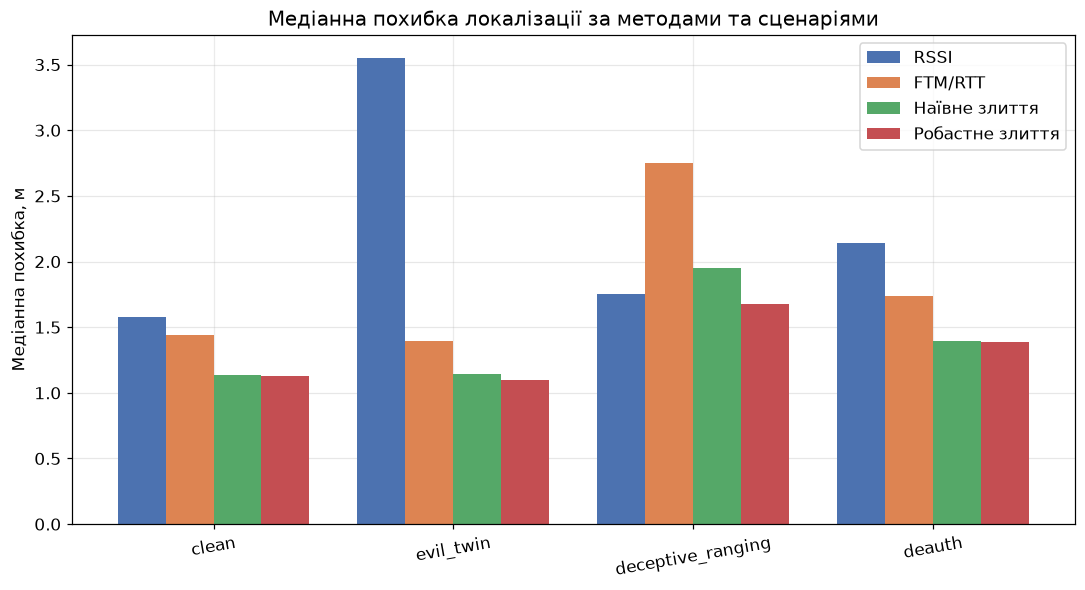

In [9]:
# ------------------------------------------------------------
# Рисунок 4. Медіанна похибка: стовпчики за методами × сценаріями
# ------------------------------------------------------------
pivot = table.pivot(index="scenario", columns="method",
                    values="median_err_m")[METHODS].reindex(SCENARIOS)
display(pivot.round(3))

fig, ax = plt.subplots(figsize=(10, 5.5))
x, w = np.arange(len(SCENARIOS)), 0.2
for k, m in enumerate(METHODS):
    ax.bar(x + (k - 1.5) * w, pivot[m].values, w, color=CMETH[m], label=LMETH[m])
ax.set(xticks=x, ylabel="Медіанна похибка, м",
       title="Медіанна похибка локалізації за методами та сценаріями")
ax.set_xticklabels(SCENARIOS, rotation=10)
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig("figures/fig4_error_bars.png"); plt.show()

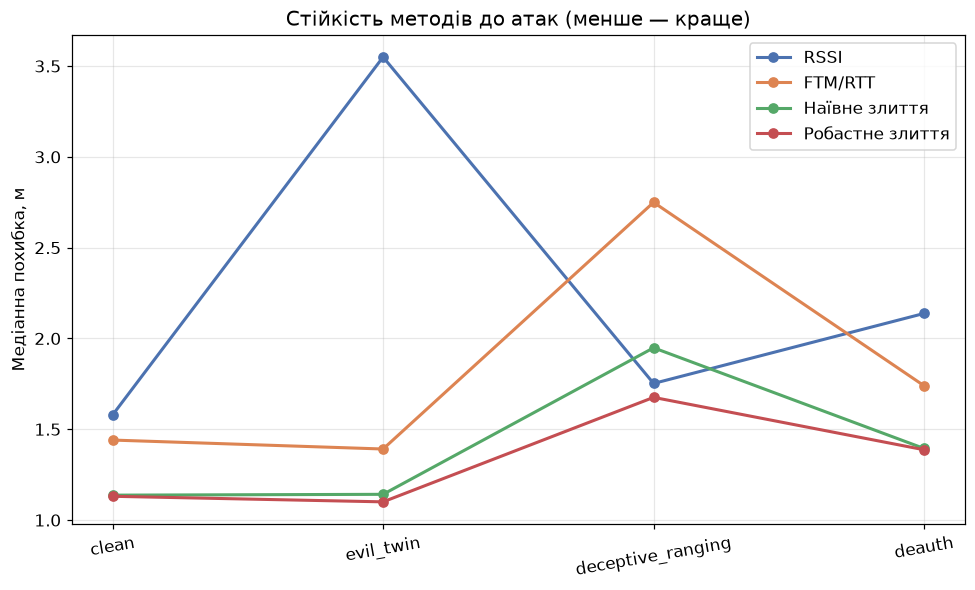

In [10]:
# ------------------------------------------------------------
# Рисунок 5. Стійкість до атак: медіанна похибка як лінії
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
for m in METHODS:
    ax.plot(SCENARIOS, pivot[m].values, "-o", lw=2, color=CMETH[m], label=LMETH[m])
ax.set(ylabel="Медіанна похибка, м", title="Стійкість методів до атак (менше — краще)")
ax.legend(); ax.grid(alpha=0.3); plt.setp(ax.get_xticklabels(), rotation=10)
fig.tight_layout(); fig.savefig("figures/fig5_robustness.png"); plt.show()

## 5. Розподіл похибки / Error distribution

Дві доповнювальні проекції розподілу похибки для сценарію **без атак**: емпіричний CDF
(яка частка подій має похибку ≤ x) та «скрипкові» діаграми (форма розподілу з медіаною).
Обидва злиття домінують над окремими модальностями на всьому діапазоні.

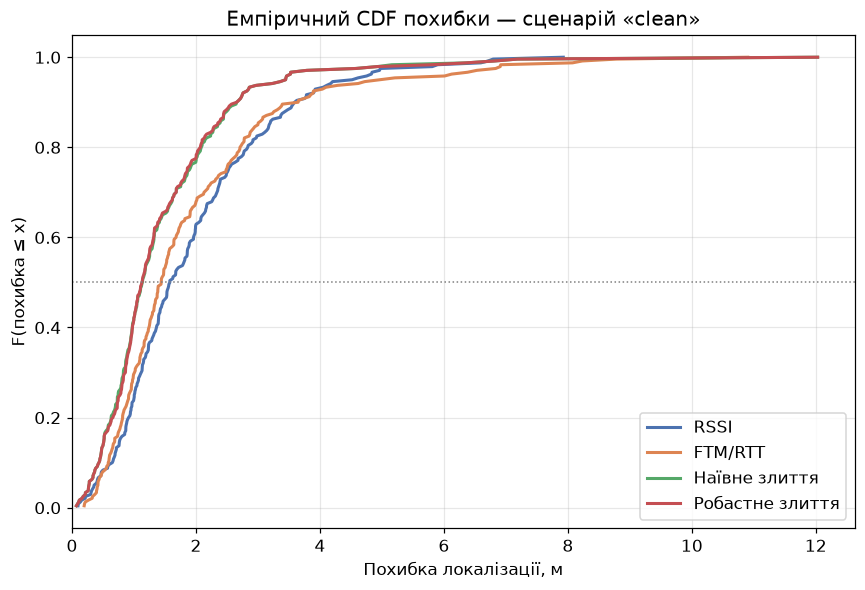

In [11]:
# ------------------------------------------------------------
# Рисунок 6. Емпіричний CDF похибки (сценарій clean)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))
for m in METHODS:
    e = np.sort(per[("clean", m)]["err"])
    ax.plot(e, np.arange(1, len(e) + 1) / len(e), lw=2, color=CMETH[m], label=LMETH[m])
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.set(xlabel="Похибка локалізації, м", ylabel="F(похибка ≤ x)", xlim=(0, None),
       title="Емпіричний CDF похибки — сценарій «clean»")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("figures/fig6_error_cdf.png"); plt.show()

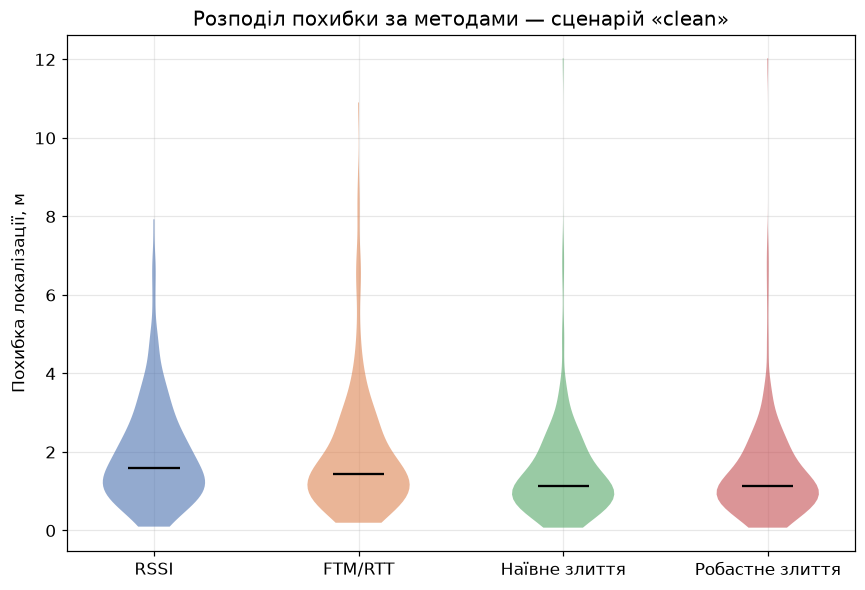

In [12]:
# ------------------------------------------------------------
# Рисунок 7. Розподіл похибки (скрипкові діаграми, сценарій clean)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))
data = [per[("clean", m)]["err"] for m in METHODS]
parts = ax.violinplot(data, showmedians=True, showextrema=False)
for pc, m in zip(parts["bodies"], METHODS):
    pc.set_facecolor(CMETH[m]); pc.set_alpha(0.6)
parts["cmedians"].set_color("black")
ax.set_xticks(range(1, len(METHODS) + 1)); ax.set_xticklabels([LMETH[m] for m in METHODS])
ax.set(ylabel="Похибка локалізації, м",
       title="Розподіл похибки за методами — сценарій «clean»")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig("figures/fig7_error_box.png"); plt.show()

## 6. Зонова атрибуція / Zone attribution

Рішення тривоги приймається за апостеріорною **ймовірністю перебування джерела в критичній
зоні**. **Pd** — виявлення істинно-критичних подій, **FAR** — хибні тривоги на дозволених
позиціях. Робастне злиття утримує Pd під атаками, коли скомпрометована модальність завалює
наївні методи. Діаграма робочих точок (Pd проти FAR) показує, що робастний метод лежить
ближче до ідеального кутка «висока Pd — низька FAR».

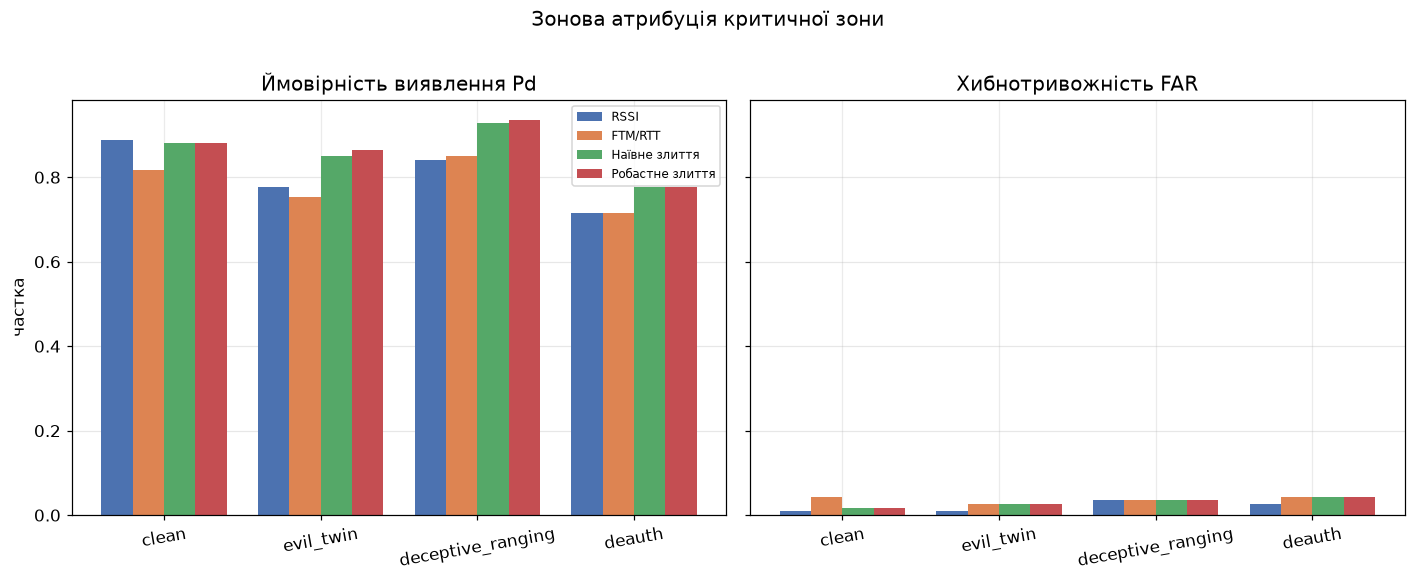

In [13]:
# ------------------------------------------------------------
# Рисунок 8. Зонова атрибуція: Pd та FAR
# ------------------------------------------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
x, w = np.arange(len(SCENARIOS)), 0.2
for k, m in enumerate(METHODS):
    pd_v = [table[(table.scenario == s) & (table.method == m)].crit_pd.values[0] for s in SCENARIOS]
    fa_v = [table[(table.scenario == s) & (table.method == m)].crit_far.values[0] for s in SCENARIOS]
    a1.bar(x + (k - 1.5) * w, pd_v, w, color=CMETH[m], label=LMETH[m])
    a2.bar(x + (k - 1.5) * w, fa_v, w, color=CMETH[m])
for a, t in ((a1, "Ймовірність виявлення Pd"), (a2, "Хибнотривожність FAR")):
    a.set_xticks(x); a.set_xticklabels(SCENARIOS, rotation=10); a.set_title(t)
    a.grid(axis="y", alpha=0.3)
a1.set_ylabel("частка"); a1.legend(fontsize=8)
fig.suptitle("Зонова атрибуція критичної зони", y=1.01)
fig.tight_layout(); fig.savefig("figures/fig8_attribution.png"); plt.show()

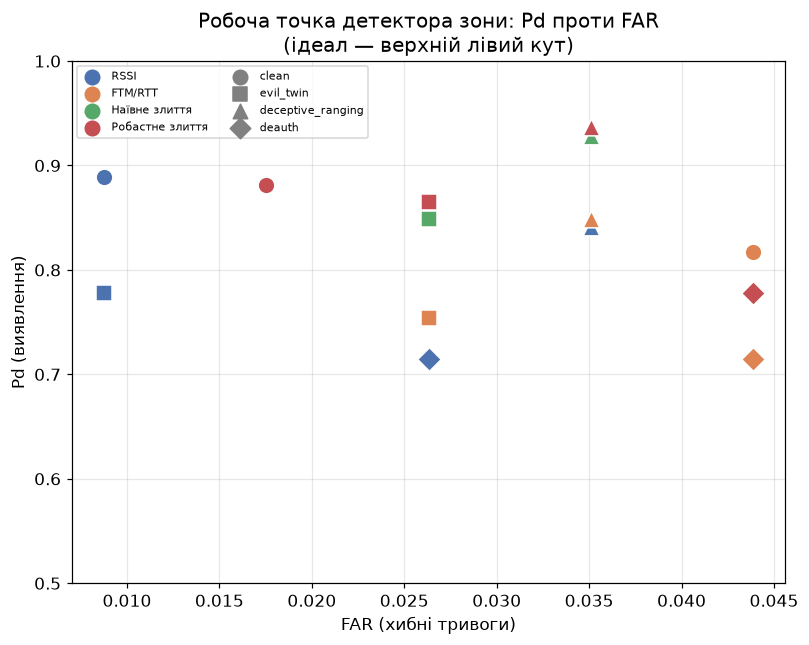

In [14]:
# ------------------------------------------------------------
# Рисунок 9. Робоча точка детектора: Pd проти FAR
# ------------------------------------------------------------
markers = {"clean": "o", "evil_twin": "s", "deceptive_ranging": "^", "deauth": "D"}
fig, ax = plt.subplots(figsize=(7.5, 6))
for m in METHODS:
    for s in SCENARIOS:
        r = table[(table.scenario == s) & (table.method == m)]
        ax.scatter(r.crit_far, r.crit_pd, s=120, color=CMETH[m], marker=markers[s],
                   edgecolors="white", zorder=3)
for m in METHODS:  ax.scatter([], [], color=CMETH[m], label=LMETH[m], s=90)
for s in SCENARIOS: ax.scatter([], [], color="gray", marker=markers[s], label=s, s=90)
ax.set(xlabel="FAR (хибні тривоги)", ylabel="Pd (виявлення)", ylim=(0.5, 1.0),
       title="Робоча точка детектора зони: Pd проти FAR\n(ідеал — верхній лівий кут)")
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("figures/fig9_pd_far.png"); plt.show()

## 7. Просторовий ефект атаки / Spatial effect of the attack

Лінії з'єднують істинну позицію з оцінкою. За **evil twin** RSSI-локалізація системно
зміщує оцінки в бік підробленого AP1 (сірі лінії тягнуться до лівого-нижнього кута);
робастне злиття виявляє викид, вилучає rogue-AP і повертає оцінки на місце.

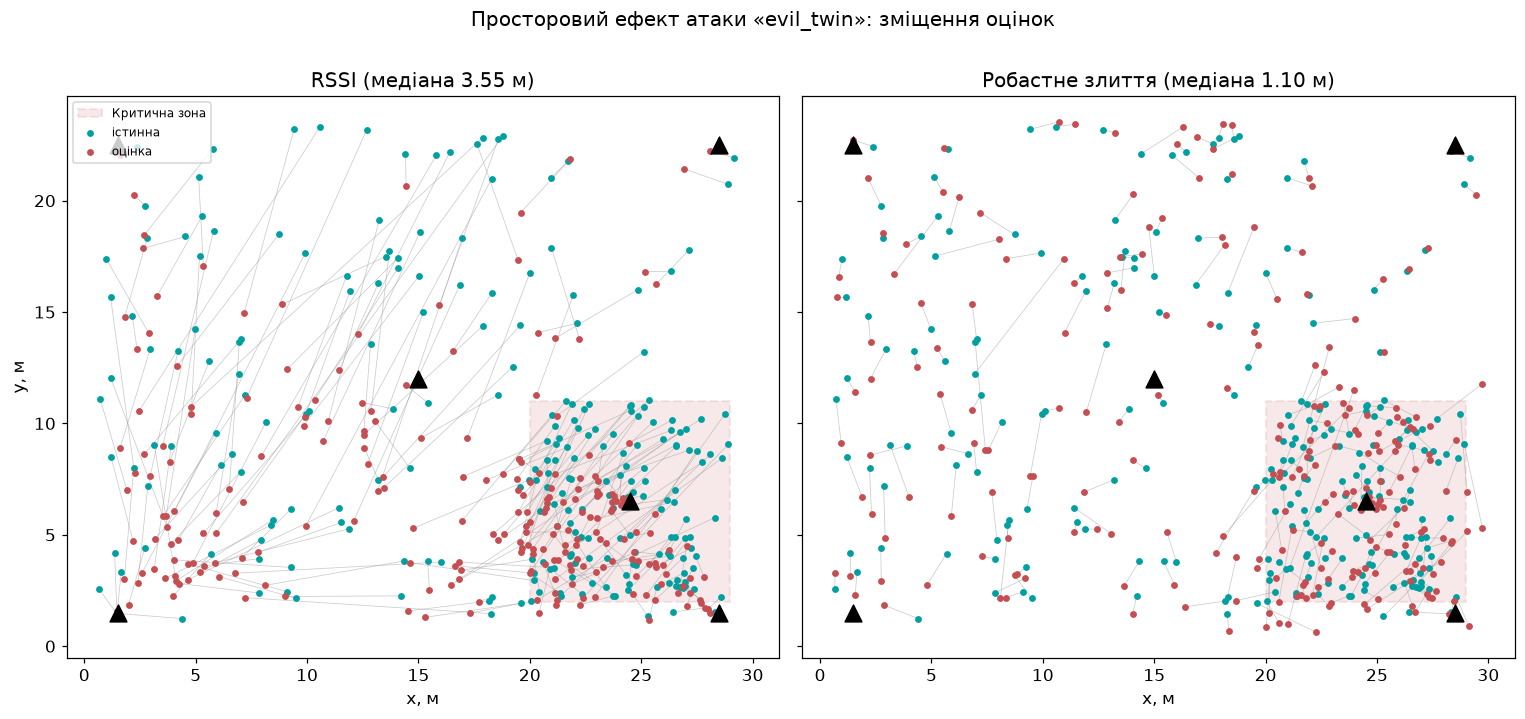

In [15]:
# ------------------------------------------------------------
# Рисунок 10. Просторове зміщення оцінок: RSSI проти робастного злиття
# ------------------------------------------------------------
scenario, pair = "evil_twin", ("rssi", "robust")
fig, axes = plt.subplots(1, 2, figsize=(14, 6.2), sharex=True, sharey=True)
for ax, m in zip(axes, pair):
    ests = per[(scenario, m)]["ests"]
    zone_patch(ax); ax.grid(False)
    for i in range(N_EVENTS):                            # лінії істина→оцінка
        ax.plot([env.pos[i, 0], ests[i, 0]], [env.pos[i, 1], ests[i, 1]],
                "-", color="#999999", lw=0.5, alpha=0.5)
    ax.scatter(*env.pos.T, s=12, c="#00A0A0", label="істинна", zorder=3)
    ax.scatter(*ests.T,    s=12, c="#C44E52", label="оцінка", zorder=3)
    ax.scatter(*APS.T, s=120, marker="^", c="black", zorder=4)
    med = np.median(np.linalg.norm(ests - env.pos, axis=1))
    ax.set(xlabel="x, м", title=f"{LMETH[m]} (медіана {med:.2f} м)"); ax.set_aspect("equal")
axes[0].set_ylabel("y, м"); axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle(f"Просторовий ефект атаки «{scenario}»: зміщення оцінок", y=1.01)
fig.tight_layout(); fig.savefig("figures/fig10_attack_shift.png"); plt.show()

## 8. Spatial Attribution Record (SAR) для SOC/SIEM

Мінімальна одиниця доказу (п. 1.5.3): оцінена позиція, невизначеність, апостеріорна
ймовірність зони, використані модальності, ознаки цілісності (`integrity_flags`) та
провенанс. Формат — **JSON по об'єкту на рядок** (JSON Lines), придатний для приймання
у SIEM. Ознака `zone_mismatch` фіксує події, де рішення про зону за оцінкою не збігається
з наївним RSSI-рішенням, — індикатор можливої маніпуляції.

In [16]:
# ============================================================
# Формування доказових записів (SAR) для SOC/SIEM
# ============================================================
def integrity_flags(env, obs):
    '''Проста ознака цілісності: розбіжність RSSI-only та робастного рішень про зону.'''
    flags = np.zeros(N_EVENTS, bool)
    for i in range(N_EVENTS):
        est_r, _, _, _ = localize_event(env, obs, i, "rssi")
        est_b, _, _, _ = localize_event(env, obs, i, "robust")
        flags[i] = bool(in_zone(est_r)[0] != in_zone(est_b)[0])
    return flags


def build_records(env, obs, method, seed, flags, n=None):
    '''Список SAR-записів (dict-ів) для перших n подій.'''
    n = N_EVENTS if n is None else n
    used = ["RSSI"] + (["FTM"] if obs.ftm_ok.any() else [])
    recs = []
    for i in range(n):
        est, sd, pz, _ = localize_event(env, obs, i, method)
        recs.append({
            "record_id": f"SAR-{seed}-{obs.scenario}-{i:04d}",
            "scenario": obs.scenario, "method": method,
            "est_x_m": round(float(est[0]), 3), "est_y_m": round(float(est[1]), 3),
            "uncertainty_sigma_m": round(sd, 3),
            "p_critical_zone": round(pz, 4),
            "zone_decision": "CRITICAL" if pz >= 0.5 else "ALLOWED",
            "modalities": used,
            "integrity_flags": {"zone_mismatch": bool(flags[i]),
                                "compromised_ap": obs.compromised.get("ap")},
            "provenance": {"seed": seed, "model": "AEGIS-RF demo", "grid_m": 0.75},
        })
    return recs


obs = scen_obs["evil_twin"]
flags = integrity_flags(env, obs)
records = build_records(env, obs, method="robust", seed=SEED, flags=flags)
with open("results/spatial_attribution_records.jsonl", "w", encoding="utf-8") as fh:
    fh.write("\n".join(json.dumps(r, ensure_ascii=False) for r in records))

print(f"Сформовано {len(records)} SAR-записів | "
      f"подій з ознакою неузгодженості: {int(flags.sum())}")
print("\nПриклад запису:")
print(json.dumps(records[0], ensure_ascii=False, indent=2))

Сформовано 240 SAR-записів | подій з ознакою неузгодженості: 33

Приклад запису:
{
  "record_id": "SAR-80211-evil_twin-0000",
  "scenario": "evil_twin",
  "method": "robust",
  "est_x_m": 28.537,
  "est_y_m": 9.276,
  "uncertainty_sigma_m": 1.254,
  "p_critical_zone": 0.919,
  "zone_decision": "CRITICAL",
  "modalities": [
    "RSSI",
    "FTM"
  ],
  "integrity_flags": {
    "zone_mismatch": false,
    "compromised_ap": "AP1"
  },
  "provenance": {
    "seed": 80211,
    "model": "AEGIS-RF demo",
    "grid_m": 0.75
  }
}


## 9. Артефакти та контрольні суми / Artifacts & checksums

Таблиці — в `results/`, рисунки — у `figures/`, доказові записи — у
`results/spatial_attribution_records.jsonl`. SHA-256 фіксують точний вміст для депозиту
й перевірки відтворюваності.

In [17]:
# ============================================================
# Маніфест SHA-256 усіх артефактів
# ============================================================
manifest = {}
for root in ("results", "figures"):
    for f in sorted(os.listdir(root)):
        p = os.path.join(root, f)
        manifest[p] = hashlib.sha256(open(p, "rb").read()).hexdigest()[:16]
with open("results/MANIFEST_sha256.json", "w") as fh:
    json.dump(manifest, fh, indent=2)

for p, h in manifest.items():
    print(f"{h}  {p}  ({os.path.getsize(p) / 1024:.1f} КБ)")

30e9d6d71bfc264f  results/metrics.csv  (2.1 КБ)
7b93632a6541603d  results/spatial_attribution_records.jsonl  (89.4 КБ)
462330a1db3ab7f4  figures/fig10_attack_shift.png  (391.3 КБ)
d32114fb65a8fa97  figures/fig1_environment.png  (106.0 КБ)
a979920016cac654  figures/fig2_radiomap.png  (82.4 КБ)
8ba3b560fa870a59  figures/fig3_posterior.png  (69.6 КБ)
73c1492c1c40677e  figures/fig4_error_bars.png  (53.9 КБ)
20975a0517d0c36d  figures/fig5_robustness.png  (115.6 КБ)
60ee85a37b3a372e  figures/fig6_error_cdf.png  (81.2 КБ)
ac581c7e69c92f10  figures/fig7_error_box.png  (56.3 КБ)
1e6c351aa22c56ed  figures/fig8_attribution.png  (66.9 КБ)
38fb88f637c0d5e1  figures/fig9_pd_far.png  (60.5 КБ)


## 10. Обмеження / Limitations

1. **Синтетичні дані.** Модель загасання, похибки FTM, частки NLOS та відмов задані
   параметрично, а не з польових вимірювань.
2. **Спрощена геометрія.** Один поверх, прямокутна критична зона, без стін/матеріалів і
   повного багатопроменевого моделювання.
3. **Модель супротивника** обмежена трьома класами атак на один AP; коаліційні та
   адаптивні атаки не розглядаються.
4. **Немає прямого емпіричного порівняння** з польовими системами.
5. Наведені числа **не можна використовувати** для сертифікації чи проєктування реальних
   систем захисту КІІ без валідації на реальних даних.

Ліцензія: MIT. Прикладний демонстраційний проєкт за Розділом 1.